In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("customer_shopping_trends_dataset.csv")

In [5]:
df.head()

,Customer_ID,Age,Gender,Location,Category,Item_Purchased,Purchase_Amount,Quantity,Payment_Method,Season,Discount_Applied,Promo_Code_Used,Subscription_Status,Shipping_Type,Review_Rating,Previous_Purchases,Frequency_of_Purchases,Purchase_Date
0,100001,61,Male,Vijayawada,Clothing,T-Shirt,2398.65,1,UPI,Summer,Yes,No,No,Standard,4.1,7,Monthly,27-10-2025
1,100002,18,Male,Kochi,Sports,Cricket Bat,4610.81,2,Credit Card,Autumn,No,No,No,Standard,4.2,8,Weekly,24-01-2025
2,100003,47,Male,Bhopal,Clothing,Jacket,854.60,3,Net Banking,Autumn,Yes,Yes,No,Same Day,4.3,19,Monthly,23-10-2024
3,100004,41,Male,Indore,Clothing,Jeans,2098.72,3,UPI,Summer,Yes,Yes,No,Same Day,4.4,12,Monthly,16-06-2024
4,100005,32,Female,Bengaluru,Books,Programming Book,765.36,1,Debit Card,Winter,No,No,Yes,Express,5.0,48,Quarterly,05-08-2024


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             5000 non-null   int64  
 1   Age                     5000 non-null   int64  
 2   Gender                  5000 non-null   object 
 3   Location                5000 non-null   object 
 4   Category                5000 non-null   object 
 5   Item_Purchased          5000 non-null   object 
 6   Purchase_Amount         5000 non-null   float64
 7   Quantity                5000 non-null   int64  
 8   Payment_Method          5000 non-null   object 
 9   Season                  5000 non-null   object 
 10  Discount_Applied        5000 non-null   object 
 11  Promo_Code_Used         5000 non-null   object 
 12  Subscription_Status     5000 non-null   object 
 13  Shipping_Type           5000 non-null   object 
 14  Review_Rating           5000 non-null   

In [7]:
df.describe()

,Customer_ID,Age,Purchase_Amount,Quantity,Review_Rating,Previous_Purchases
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,102500.500000,43.809800,4484.848868,2.982000,4.187920,16.733800
std,1443.520003,15.418754,5012.218147,1.419464,0.480795,12.489457
min,100001.000000,18.000000,203.670000,1.000000,2.100000,0.000000
25%,101250.750000,31.000000,1405.500000,2.000000,3.900000,8.000000
50%,102500.500000,44.000000,2505.595000,3.000000,4.200000,14.000000
75%,103750.250000,57.000000,5368.122500,4.000000,4.500000,20.000000
max,105000.000000,70.000000,24998.470000,5.000000,5.000000,50.000000


In [8]:
df.isnull().sum()

Customer_ID               0
Age                       0
Gender                    0
Location                  0
Category                  0
Item_Purchased            0
Purchase_Amount           0
Quantity                  0
Payment_Method            0
Season                    0
Discount_Applied          0
Promo_Code_Used           0
Subscription_Status       0
Shipping_Type             0
Review_Rating             0
Previous_Purchases        0
Frequency_of_Purchases    0
Purchase_Date             0
dtype: int64

In [9]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.dtypes

Customer_ID                 int64
Age                         int64
Gender                     object
Location                   object
Category                   object
Item_Purchased             object
Purchase_Amount           float64
Quantity                    int64
Payment_Method             object
Season                     object
Discount_Applied           object
Promo_Code_Used            object
Subscription_Status        object
Shipping_Type              object
Review_Rating             float64
Previous_Purchases          int64
Frequency_of_Purchases     object
Purchase_Date              object
dtype: object

In [13]:
df["Purchase_Amount"].sum()

np.float64(22424244.339999996)

In [14]:
df["Purchase_Amount"].mean()

np.float64(4484.848867999999)

In [15]:
df["Purchase_Amount"].max()

np.float64(24998.47)

In [16]:
df["Purchase_Amount"].min()

np.float64(203.67)

CATEGORY THAT GENERATES HIGHEST SALES

In [17]:
category_sales = df.groupby("Category")["Purchase_Amount"].sum().sort_values(ascending=False)
print(category_sales)

Category
Electronics    9428030.90
Sports         4066216.44
Footwear       2562176.48
Home Decor     1976790.86
Clothing       1772770.86
Beauty          964498.22
Books           864732.33
Grocery         789028.25
Name: Purchase_Amount, dtype: float64


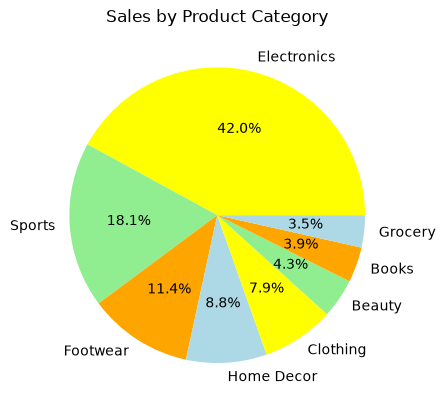

In [18]:
category_sales.plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["yellow", "lightgreen", "orange", "lightblue"]
)

plt.title("Sales by Product Category")
plt.ylabel("")
plt.show()

PRODUCT THAT GENERATE MOST SALE

In [19]:
product_sales = df.groupby("Item_Purchased")["Purchase_Amount"].sum().sort_values(ascending=False)
print(product_sales.head(10))

Item_Purchased
Tablet           1990545.33
Camera           1682601.56
Smart Watch      1603769.19
Laptop           1442677.80
Headphones       1399778.63
Smartphone       1308658.39
Dumbbells        1044544.57
Tennis Racket     839876.32
Yoga Mat          831053.56
Cricket Bat       728697.28
Name: Purchase_Amount, dtype: float64


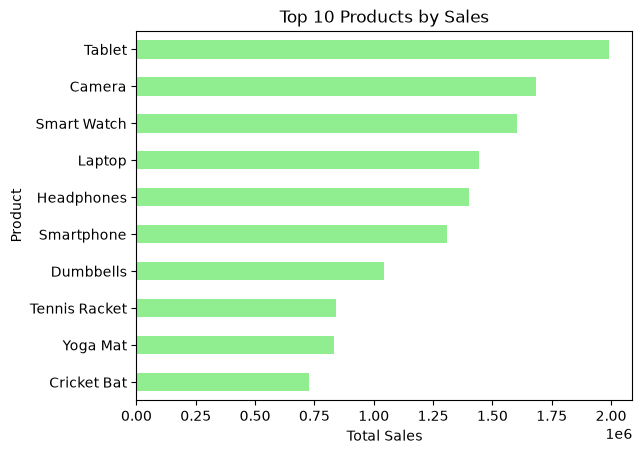

In [20]:
product_sales.head(10).plot(kind="barh", color="lightgreen")

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.show()

LOCATION WHICH GENERATES THE HIGHEST SALES

In [21]:
location_sales = df.groupby("Location")["Purchase_Amount"].sum().sort_values(ascending=False)
print(location_sales)

Location
Ahmedabad        1304305.88
Mumbai           1290004.38
Hyderabad        1279940.67
Coimbatore       1263618.22
Mysuru           1261683.64
Vijayawada       1243889.37
Indore           1174214.86
Kochi            1168494.19
Chennai          1155620.91
Visakhapatnam    1142593.14
Patna            1119635.35
Delhi            1109087.36
Nagpur           1087229.69
Bhopal           1064928.42
Kolkata          1061998.02
Surat             997415.15
Lucknow           954670.24
Jaipur            948440.11
Pune              929732.46
Bengaluru         866742.28
Name: Purchase_Amount, dtype: float64


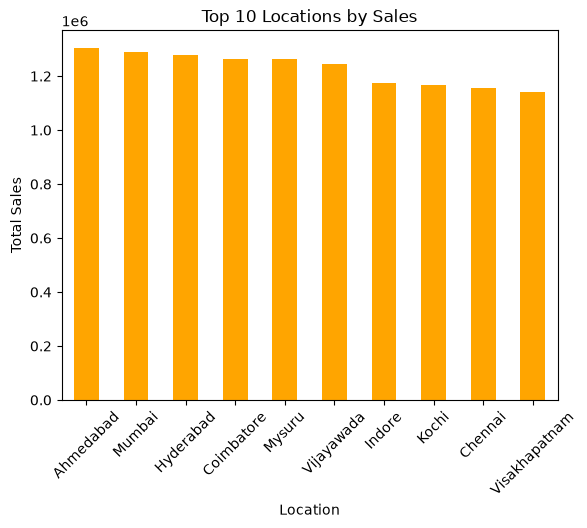

In [22]:
location_sales.head(10).plot(kind="bar", color="orange")

plt.title("Top 10 Locations by Sales")
plt.xlabel("Location")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

SEASON THAT GENERATES HIGHEST SALES

In [23]:
season_sales = df.groupby("Season")["Purchase_Amount"].sum().sort_values(ascending=False)
print(season_sales)

Season
Winter    5714849.72
Spring    5623546.30
Autumn    5566654.21
Summer    5519194.11
Name: Purchase_Amount, dtype: float64


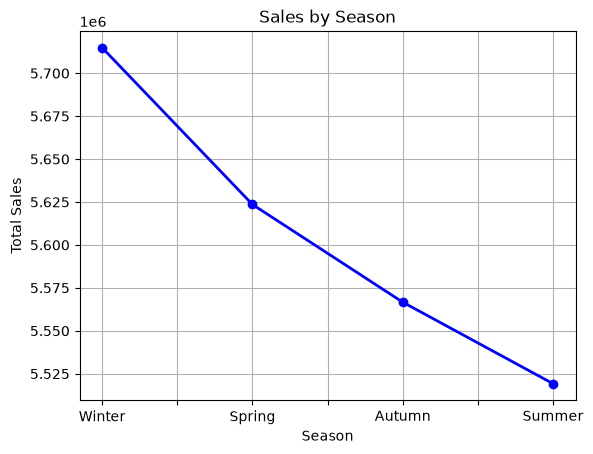

In [24]:
season_sales.plot(
    kind="line",
    color="blue",
    marker="o",
    linewidth=2
)

plt.title("Sales by Season")
plt.xlabel("Season")
plt.ylabel("Total Sales")
plt.grid()
plt.show()

GENDER THAT CONTRIBUTE MORE SALES

In [25]:
gender_sales = df.groupby("Gender")["Purchase_Amount"].sum().sort_values(ascending=False)
print(gender_sales)

Gender
Female    11312943.27
Male      11111301.07
Name: Purchase_Amount, dtype: float64


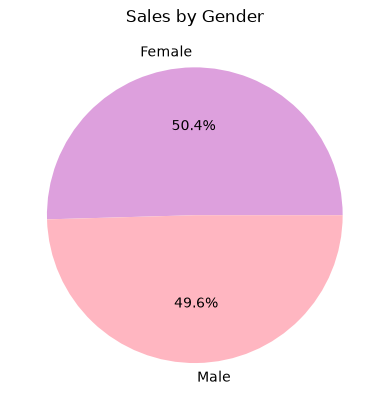

In [26]:
gender_sales.plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["plum", "lightpink"]
)

plt.title("Sales by Gender")
plt.ylabel("")
plt.show()

CUSTOMER AGE ANALYSIS

In [27]:
bins = [0, 25, 35, 45, 55, 100]
labels = ["18-25", "26-35", "36-45", "46-55", "56+"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

In [28]:
age_sales = df.groupby("Age_Group", observed=False)["Purchase_Amount"].sum()
print(age_sales)

Age_Group
18-25    3644806.60
26-35    4321770.47
36-45    4327696.86
46-55    3931668.97
56+      6198301.44
Name: Purchase_Amount, dtype: float64


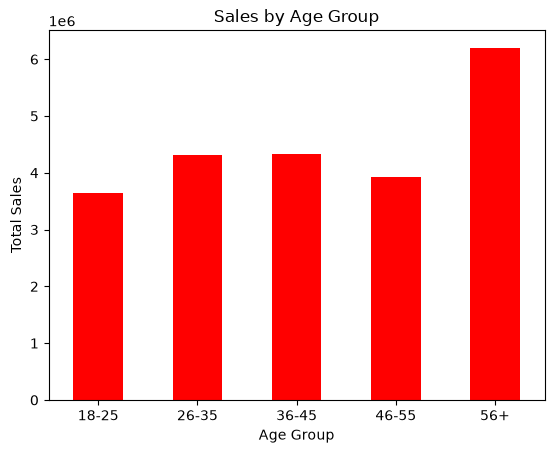

In [29]:
age_sales.plot(kind="bar", color="red")

plt.title("Sales by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

MOST USED PAYMENTMETHOD

In [30]:
payment_count = df["Payment_Method"].value_counts()
print(payment_count)

Payment_Method
Debit Card     1029
UPI            1011
Credit Card    1003
Cash           1002
Net Banking     955
Name: count, dtype: int64


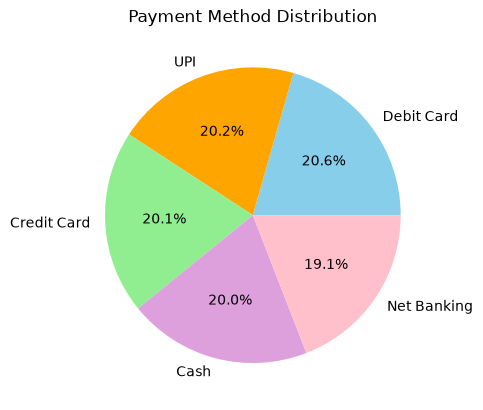

In [31]:
payment_count.plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["skyblue", "orange", "lightgreen", "plum", "pink"]
)

plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

Subscription Status Analysis

In [32]:
subscription_sales = df.groupby("Subscription_Status")["Purchase_Amount"].sum()
print(subscription_sales)

Subscription_Status
No     14292671.05
Yes     8131573.29
Name: Purchase_Amount, dtype: float64


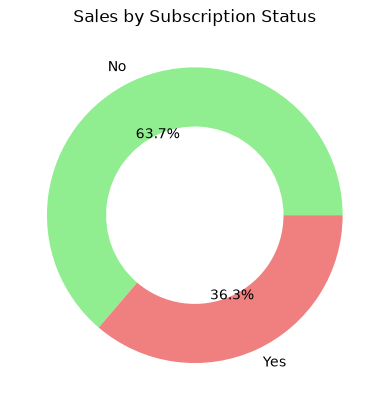

In [33]:
subscription_sales.plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["lightgreen", "lightcoral"],
    wedgeprops={"width": 0.4}
)

plt.title("Sales by Subscription Status")
plt.ylabel("")
plt.show()

Discount Analysis

In [34]:
discount_sales = df.groupby("Discount_Applied")["Purchase_Amount"].sum()
print(discount_sales)

Discount_Applied
No     12019783.20
Yes    10404461.14
Name: Purchase_Amount, dtype: float64


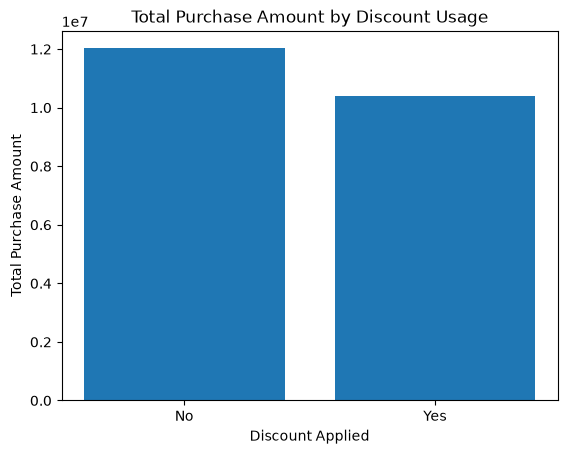

In [35]:
discount_sales = df.groupby("Discount_Applied")["Purchase_Amount"].sum()

plt.bar(discount_sales.index, discount_sales.values)

plt.title("Total Purchase Amount by Discount Usage")
plt.xlabel("Discount Applied")
plt.ylabel("Total Purchase Amount")

plt.show()

Most Frequently Purchased Products

In [36]:
df["Item_Purchased"].value_counts().head(10)

Item_Purchased
Dumbbells        158
Sandals          153
Curtains         148
Running Shoes    143
Biography        140
Yoga Mat         140
Perfume          138
Tennis Racket    136
Novel            133
Carpet           130
Name: count, dtype: int64

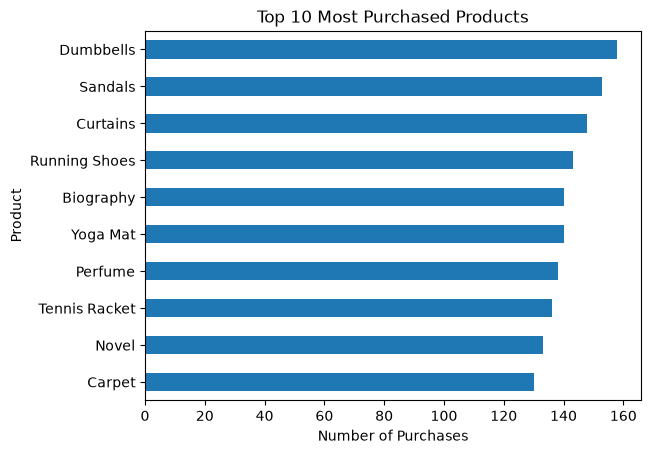

In [37]:
df["Item_Purchased"].value_counts().head(10).plot(kind="barh")

plt.title("Top 10 Most Purchased Products")
plt.xlabel("Number of Purchases")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.show()

Key Insights


Electronics is the strongest product category, generating about 9.43M in sales, much higher than other categories. Sports is the second-highest at about 4.07M.

Tablet is the highest-selling product by revenue, generating about 1.99M, followed by Camera (1.68M) and Smart Watch (1.60M). Electronics products clearly dominate the top-selling products.

Ahmedabad has the highest sales, at approximately 1.30M, followed closely by Mumbai (1.29M) and Hyderabad (1.28M). Sales are distributed fairly well across several major locations.

Female customers contribute slightly more sales (11.31M) than male customers (11.11M). The difference is very small, showing that both genders are important customer segments.

Winter generates the highest seasonal sales at approximately 5.71M, while Summer has the lowest at 5.52M. However, the difference between seasons is small, indicating relatively stable demand throughout the year.
Customers aged 36–45 generate the highest sales, approximately 4.33M, closely followed by customers aged 26–35 (4.32M). These age groups are therefore particularly valuable customer segments.

Cash is the leading payment method, contributing approximately 4.66M in purchases, followed by Debit Card (4.57M). Payment preferences are nevertheless fairly evenly distributed.

Non-subscribers generate significantly more total sales (14.29M) than subscribers (8.13M). This suggests a strong opportunity to convert existing non-subscribers into subscription customers.

Customers using discounts have a slightly higher average purchase amount (4,514) than customers without discounts (4,460). This suggests discounts may encourage somewhat higher spending, although the difference is modest.

Conclusion

Electronics is the main revenue driver, so the business should prioritize inventory, promotions, and marketing for high-performing electronics such as Tablets, Cameras, and Smart Watches.

Customers aged 26–45 are major revenue contributors, making them an important target audience for personalized campaigns and product recommendations.

Sales are fairly balanced across gender, seasons, and payment methods, reducing dependence on a single customer group or sales period.
Ahmedabad, Mumbai, and Hyderabad are leading markets, so the business can strengthen marketing and inventory in these locations while studying their strategies for lower-performing locations.

The biggest growth opportunity is customer conversion and retention. Since non-subscribers contribute a large portion of sales, subscription benefits, loyalty rewards, and targeted offers could convert them into long-term customers.